# SimpleGPT - Training on Google Colab
Train a decoder-only GPT from scratch using the project's own modules.

## 1. Mount Google Drive (optional, for saving checkpoints)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone the repo

In [2]:
%cd /content
![ -d simple-chatbot/.git ] || git clone https://github.com/mrroy-dev/simple-chatbot.git
%cd /content/simple-chatbot

/content
/content/simple-chatbot


## 3. Install dependencies

In [3]:
!pip install torch pyyaml tqdm


## 4. Check GPU

In [4]:
import torch
# IMPORTANT: If you get a CUDA error, do Runtime -> Restart runtime
try:
    torch.cuda.synchronize()
except Exception:
    print('CUDA error detected from previous run. Restart runtime and re-run.')
    raise

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB


## 5. Load or generate training data

In [5]:
import json, os, random, sys
os.makedirs('data', exist_ok=True)
random.seed(42)

data_path = 'data/pairs_train.json'
if os.path.exists(data_path):
    print(f'Loading {data_path}...')
    with open(data_path, 'r') as f:
        all_pairs = json.load(f)
    print(f'Total entries: {len(all_pairs)}')
    random.shuffle(all_pairs)
    MAX_EXAMPLES = min(30000, len(all_pairs))
    all_pairs = all_pairs[:MAX_EXAMPLES]
else:
    print(f'{data_path} not found. Generating synthetic data...')
    facts = {
        'python': 'Python is a high-level programming language known for readability.',
        'ml': 'Machine learning enables systems to learn from data without explicit programming.',
        'dl': 'Deep learning uses multi-layered neural networks to learn from data.',
        'nn': 'Neural networks are computing systems inspired by biological brains.',
        'transformers': 'Transformers use self-attention to process sequential data in parallel.',
        'gpt': 'GPT is a language model that generates human-like text.',
        'pytorch': 'PyTorch is an open-source ML framework by Meta AI.',
        'gd': 'Gradient descent minimizes loss by iteratively updating parameters.',
        'overfitting': 'Overfitting occurs when a model memorizes noise in training data.',
        'attention': 'Attention lets models focus on relevant parts of input.',
        'nlp': 'NLP enables computers to understand and generate human language.',
        'cnn': 'CNNs use convolutional layers to process grid-like data such as images.',
        'rnn': 'RNNs process sequences by maintaining a hidden state across time steps.',
        'lstm': 'LSTM networks solve vanishing gradients using gated cell states.',
        'gan': 'GANs use a generator and discriminator that compete to create realistic data.',
        'dropout': 'Dropout prevents overfitting by randomly dropping neurons during training.',
        'embedding': 'Embeddings map discrete tokens to dense vector representations.',
        'supervised': 'Supervised learning trains on labeled input-output pairs.',
        'rl': 'Reinforcement learning trains agents via rewards and penalties.',
        'backprop': 'Backpropagation computes gradients using the chain rule.',
    }
    questions = ['What is {t}?', 'Explain {t}', 'Tell me about {t}', 'Describe {t}', 'How does {t} work?']
    all_pairs = []
    for topic, fact in facts.items():
        q = random.choice(questions).format(t=topic)
        all_pairs.append({'context': f'<bos> <user> {q}', 'response': fact})
    for _ in range(500):
        t = random.choice(list(facts.keys()))
        q = random.choice(questions).format(t=t)
        all_pairs.append({'context': f'<bos> <user> {q}', 'response': facts[t]})
    print(f'Generated {len(all_pairs)} synthetic pairs')

split = int(len(all_pairs) * 0.95)
train = all_pairs[:split]
val = all_pairs[split:]
with open('data/pairs_train_subset.json', 'w') as f:
    json.dump(train, f)
with open('data/pairs_val_subset.json', 'w') as f:
    json.dump(val, f)
print(f'Using {len(train)} train + {len(val)} val pairs')


data/pairs_train.json not found. Generating synthetic data...
Generated 520 synthetic pairs
Using 494 train + 26 val pairs


## 6. Import project modules
Uses the project's own BPETokenizer (with byte_encoder fix), ModelConfig, SimpleGPT (GQA, SwiGLU, RoPE, RMSNorm), and ConversationDataset.

In [6]:
import os
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from simple_gpt import ModelConfig, SimpleGPT, BPETokenizer
from simple_gpt.datasets.dataset import ConversationDataset

print('Imports OK')

Imports OK


## 7. Build tokenizer on the training data

In [7]:
# Collect all text for training the BPE tokenizer
all_texts = []
for item in train:
    all_texts.append(item['context'])
    all_texts.append(item['response'])

tok = BPETokenizer()
tok._build_vocab(all_texts, min_freq=2, max_vocab_size=8000)
tokenizer_vocab_size = len(tok)
print(f'Tokenizer: __len__={tokenizer_vocab_size}  entries={len(tok.vocab)}')
print(f'Special IDs: {tok.special_ids}')
print(f'PAD={tok.pad_id()} BOS={tok.bos_id()} EOS={tok.eos_id()}')


Tokenizer: __len__=800  entries=672  max_encoded_id=799
Special IDs: {'pad': 256, 'unk': 257, 'bos': 274, 'eos': 259, 'user': 260, 'bot': 261, 'system': 262, 'tool': 263}
PAD=256 BOS=274 EOS=259


## 8. Create model using project's ModelConfig

In [8]:
config = ModelConfig(
    vocab_size=tokenizer_vocab_size,
    block_size=256,
    n_layer=6,
    n_head=8,
    n_kv_head=4,
    n_embd=384,
    dropout=0.1,
    embd_dropout=0.1,
    weight_tying=True,
)
print(f'Model params: {sum(p.numel() for p in SimpleGPT(config).parameters()):,}')

model = SimpleGPT(config).to(device)
print(f'Model on {device} (vocab_size={config.vocab_size})')

Model params: 10,044,288
Model on cuda (vocab_size=800)


## 9. Create datasets and data loaders

In [9]:
BATCH_SIZE = 32

train_ds = ConversationDataset(train, tok, seq_len=config.block_size)
val_ds = ConversationDataset(val, tok, seq_len=config.block_size)

max_dataset_id = 0
for x, y, _, _ in train_ds:
    max_dataset_id = max(max_dataset_id, x.max().item(), y.max().item())
if max_dataset_id >= config.vocab_size:
    raise ValueError(
        f'dataset emits id {max_dataset_id}, but model vocab_size is {config.vocab_size}. '
        'Re-run cells 7, 8, and 9 in order so the model is rebuilt with the expanded vocab_size.'
    )

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f'Train: {len(train_ds)} examples, {len(train_loader)} batches, max_dataset_id={max_dataset_id}')
print(f'Val: {len(val_ds)} examples, {len(val_loader)} batches')

Train: 494 examples, 15 batches, max_dataset_id=799
Val: 26 examples, 1 batches


## 10. Training setup
AdamW with weight decay, warmup-cosine LR scheduler.

In [10]:
import math

LR = 3e-4
WARMUP_STEPS = 50
MAX_STEPS = 5000
LOG_EVERY = 10
VAL_EVERY = 100

# AdamW with separate weight decay
decay_params = []
no_decay_params = []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if param.ndim < 2 or 'bias' in name or 'norm' in name or 'ln' in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': decay_params, 'weight_decay': 0.1},
    {'params': no_decay_params, 'weight_decay': 0.0},
], lr=LR, betas=(0.9, 0.95), eps=1e-8, fused=True)

def get_lr(step):
    if step < WARMUP_STEPS:
        return LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(MAX_STEPS - WARMUP_STEPS, 1)
    return LR * 0.5 * (1 + math.cos(math.pi * progress))

# Cosine schedule (will be updated per step)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

print('Optimizer & scheduler ready')

Optimizer & scheduler ready


## 11. Training loop

In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
print('CUDA_LAUNCH_BLOCKING=1 set')

from tqdm.notebook import tqdm

global_step = 0
best_val_loss = float('inf')
train_losses = []
val_losses = []

model.train()
pbar = tqdm(total=MAX_STEPS, desc='Training')

# Debug info
print(f'Model vocab_size = {model.config.vocab_size}')
print(f'Tokenizer len = {len(tok)}')
print(f'Tokenizer vocab entries = {len(tok.vocab)}')
print(f'block_size = {config.block_size}')

while global_step < MAX_STEPS:
    for batch in train_loader:
        if global_step >= MAX_STEPS:
            break

        x, y, m, _ = batch

        # === PRE-FORWARD ASSERTIONS ===
        assert x.min() >= 0, f'x.min()={x.min()} < 0'
        assert y.min() >= 0, f'y.min()={y.min()} < 0'
        assert x.max() < model.config.vocab_size, \
            f'x.max()={x.max()} >= vocab_size={model.config.vocab_size}'
        assert y.max() < model.config.vocab_size, \
            f'y.max()={y.max()} >= vocab_size={model.config.vocab_size}'
        assert x.shape[1] <= model.block_size, \
            f'seq_len={x.shape[1]} > block_size={model.block_size}'

        if global_step == 0:
            print(f'First batch: x.shape={x.shape}, x.min={x.min()}, x.max={x.max()}, '
                  f'y.min={y.min()}, y.max={y.max()}, block_size={model.block_size}')

        x, y, m = x.to(device), y.to(device), m.to(device)

        logits, loss, _ = model(x, targets=y, loss_mask=m)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        global_step += 1
        pbar.update(1)

        if global_step % LOG_EVERY == 0:
            train_losses.append((global_step, loss.item()))
            pbar.set_postfix(loss=f'{loss.item():.4f}')

        if global_step % VAL_EVERY == 0:
            model.eval()
            val_loss_total = 0.0
            val_batches = 0
            with torch.no_grad():
                for vx, vy, vm, _ in val_loader:
                    vx, vy, vm = vx.to(device), vy.to(device), vm.to(device)
                    _, vloss, _ = model(vx, targets=vy, loss_mask=vm)
                    val_loss_total += vloss.item()
                    val_batches += 1
            val_loss = val_loss_total / max(val_batches, 1)
            val_losses.append((global_step, val_loss))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'model_state': model.state_dict(),
                    'model_config': config,
                    'tokenizer': tok,
                    'step': global_step,
                    'val_loss': val_loss,
                }, 'checkpoint_best.pt')
                print(f'Step {global_step}: new best val_loss={val_loss:.4f} (saved)')
            else:
                print(f'Step {global_step}: val_loss={val_loss:.4f}')

            model.train()

pbar.close()
print(f'Done! Best val_loss: {best_val_loss:.4f}')

torch.save({
    'model_state': model.state_dict(),
    'model_config': config,
    'tokenizer': tok,
    'step': global_step,
    'final_loss': loss.item(),
}, 'checkpoint_final.pt')
print('Final checkpoint saved')


CUDA_LAUNCH_BLOCKING=1 set


Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Model vocab_size = 800
Tokenizer len = 672
Tokenizer vocab entries = 672
block_size = 256
First batch: x.shape=torch.Size([32, 255]), x.min=46, x.max=775, y.min=46, y.max=775, block_size=256
Step 100: new best val_loss=6.6628 (saved)
Step 200: new best val_loss=6.5918 (saved)
Step 300: new best val_loss=6.5241 (saved)
Step 400: new best val_loss=6.4604 (saved)
Step 500: new best val_loss=6.4009 (saved)
Step 600: new best val_loss=6.3461 (saved)
Step 700: new best val_loss=6.2953 (saved)
Step 800: new best val_loss=6.2483 (saved)
Step 900: new best val_loss=6.2050 (saved)
Step 1000: new best val_loss=6.1650 (saved)
Step 1100: new best val_loss=6.1278 (saved)
Step 1200: new best val_loss=6.0935 (saved)
Step 1300: new best val_loss=6.0615 (saved)
Step 1400: new best val_loss=6.0319 (saved)
Step 1500: new best val_loss=6.0044 (saved)
Step 1600: new best val_loss=5.9789 (saved)
Step 1700: new best val_loss=5.9552 (saved)
Step 1800: new best val_loss=5.9332 (saved)
Step 1900: new best val_lo

In [ ]:
# Validate dataset before training
print('=== Dataset Validation ===')
vocab_size = len(tok)
vocab_entries = len(tok.vocab)
print(f'Tokenizer: len(tok)={vocab_size}, entries={vocab_entries}')
print(f'Special IDs: {tok.special_ids}')
print(f'Max inv_vocab key: {max(tok.inv_vocab.keys())}')
missing = [k for k in range(vocab_size) if k not in tok.inv_vocab]
print(f'Missing inv_vocab keys: {missing[:10]}...' if len(missing) > 10 else f'Missing inv_vocab keys: {missing}')

max_seen = 0
for i in range(len(train_ds)):
    x, y, m, _ = train_ds[i]
    mx = max(x.max().item(), y.max().item())
    if mx > max_seen:
        max_seen = mx
    if mx >= vocab_size:
        print(f'FAIL example {i}: max_id={mx} vocab_size={vocab_size}')
        import sys
        sys.exit(1)
print(f'OK: vocab_size={vocab_size}, max_seen_id={max_seen}')

# Test one forward+backward pass
from torch.utils.data import DataLoader
test_loader = DataLoader(train_ds, batch_size=2, shuffle=False, num_workers=0, pin_memory=False)
tx, ty, tm, _ = next(iter(test_loader))
tx, ty, tm = tx.to(device), ty.to(device), tm.to(device)
tlogits, tloss, _ = model(tx, targets=ty, loss_mask=tm)
print(f'Validation forward: loss={tloss.item():.4f}')
tloss.backward()
print('Validation backward: OK')
model.zero_grad()
print('=== Validation Passed ===')


=== Dataset Validation ===
Tokenizer: len(tok)=672, effective_vocab_size=800, entries=672
Model vocab_size: 800
Special IDs: {'pad': 256, 'unk': 257, 'bos': 274, 'eos': 259, 'user': 260, 'bot': 261, 'system': 262, 'tool': 263}
Max inv_vocab key: 799
Missing inv_vocab keys: [128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157]...
OK: vocab_size=800, max_seen_id=799
Validation forward: loss=6.2575
Validation backward: OK
=== Validation Passed ===


## 12. Plot training curves

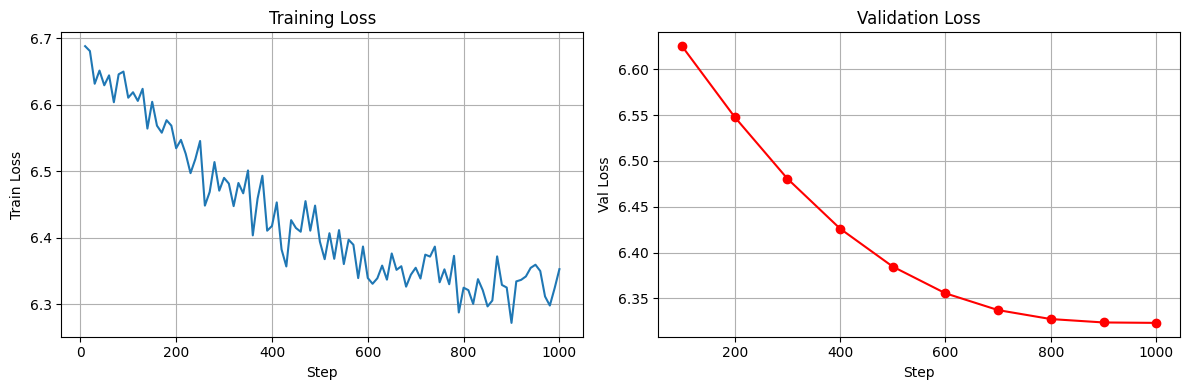

Final train loss: 6.3526  Best val loss: 6.3233


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
if train_losses:
    steps, losses = zip(*train_losses)
    plt.plot(steps, losses)
plt.xlabel('Step')
plt.ylabel('Train Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
if val_losses:
    steps, losses = zip(*val_losses)
    plt.plot(steps, losses, 'r-o')
plt.xlabel('Step')
plt.ylabel('Val Loss')
plt.title('Validation Loss')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()
print(f'Final train loss: {train_losses[-1][1]:.4f}  Best val loss: {best_val_loss:.4f}')

## 13. Load best checkpoint and chat

In [ ]:
# Load best checkpoint
# This checkpoint includes ModelConfig and tokenizer objects, so PyTorch 2.6+
# needs weights_only=False. Only use this for checkpoints you created/trust.
ckpt = torch.load('checkpoint_best.pt', map_location=device, weights_only=False)
model = SimpleGPT(ckpt['model_config']).to(device)
model.load_state_dict(ckpt['model_state'])
tok = ckpt['tokenizer']
model.eval()
print(f'Loaded best checkpoint from step {ckpt["step"]} (val_loss={ckpt["val_loss"]:.4f})')

Loaded best checkpoint from step 1000 (val_loss=6.3233)


## 14. Chat function

In [ ]:
def clean_reply(text):
    for marker in ('<user>', '<bot>', '<bos>', '<eos>', '<pad>', '<system>', '<tool>'):
        if marker in text:
            text = text.split(marker)[0]
    text = ''.join(ch for ch in text if ch == '\n' or ch == '\t' or ord(ch) >= 32)
    return ' '.join(text.strip().split())


def build_chat_ids(tok, user_text, history=None):
    ids = [tok.bos_id()]
    for old_user, old_bot in (history or [])[-2:]:
        ids.extend([tok.user_id(), *tok.encode(old_user), tok.bot_id(), *tok.encode(old_bot)])
    ids.extend([tok.user_id(), *tok.encode(user_text), tok.bot_id()])
    return ids


@torch.no_grad()
def generate_reply(model, tok, user_text, history=None, max_new=48, temp=0.6, top_k=20, top_p=0.8, rep_penalty=1.15):
    input_ids = build_chat_ids(tok, user_text, history)
    if len(input_ids) > model.block_size:
        input_ids = input_ids[-model.block_size:]
    idx = torch.tensor([input_ids], dtype=torch.long, device=device)
    generated = []

    stop_ids = {tok.eos_id(), tok.user_id(), tok.bot_id(), tok.bos_id(), tok.pad_id(), tok.system_id(), tok.tool_id()}
    banned_ids = stop_ids - {tok.eos_id()}

    for _ in range(max_new):
        context = idx[:, -model.block_size:]
        logits, _, _ = model(context)
        logits = logits[:, -1, :]

        for tid in banned_ids:
            if 0 <= tid < logits.size(-1):
                logits[:, tid] = float('-inf')

        if rep_penalty is not None:
            for tid in set(generated):
                if 0 <= tid < logits.size(-1):
                    logits[0, tid] /= rep_penalty

        logits = logits / max(temp, 1e-5)

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        if top_p is not None:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_mask = cum_probs > top_p
            sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
            sorted_mask[..., 0] = 0
            remove = sorted_mask.scatter(1, sorted_indices, sorted_mask)
            logits[remove] = float('-inf')

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        token_id = next_id.item()

        if token_id in stop_ids:
            break

        generated.append(token_id)
        idx = torch.cat([idx, next_id], dim=1)

    return clean_reply(tok.decode(generated))


def chat():
    print('\n=== SimpleGPT Chat v2 ===')
    print('Type "quit" to exit, "clear" to reset history\n')
    history = []
    while True:
        user = input('You: ').strip()
        if user.lower() == 'quit':
            break
        if user.lower() == 'clear':
            history = []
            print('History cleared')
            continue
        if not user:
            continue
        response = generate_reply(model, tok, user, history=history)
        if not response:
            response = '(no confident reply yet)'
        print(f'Bot: {response}')
        history.append((user, response))


print('Chat cell loaded: v2 prompt-safe generation')
chat()


=== SimpleGPT Chat ===
Type "quit" to exit, "clear" to reset history

Bot:  <user> What is python in in sequential systems cell cell biological learn systemsK
Bot:  <user> <user> What is python <bot> <user> What is python in in sequential systems cell cell biological learn systemsK <user> what is python gd E o gan by-level by gd5 uses iterativ state Meta memorizes prevents<bos data convolowor does Meta mem memow
Du to representations gri learn Meta forIain hiddattention memizesRNNs gd attentionain representations to o learn to convol by learnow) gdbedd convol learn representations learn
 to
 knownworku ag data to o knownGradientGradient data gen Meta by memorizes
Bot:  <user> <user> What is python <bot> <user> What is python in in sequential systems cell cell biological learn systemsK <user> what is python <bot> <user> <user> What is python <bot> <user> What is python in in sequential systems cell cell biological learn systemsK <user> what is python gd E o gan by-level by gd5 uses

: 

## 15. Export to Google Drive

In [ ]:
import shutil
shutil.copy('checkpoint_best.pt', '/content/drive/MyDrive/') if os.path.exists('checkpoint_best.pt') else None
shutil.copy('checkpoint_final.pt', '/content/drive/MyDrive/') if os.path.exists('checkpoint_final.pt') else None
print('Copied to Drive' if os.path.exists('/content/drive') else 'Drive not mounted, skip export')